# Part E: Tree-Based Regression Models
**Robust Regression Engine**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"D:\Python_rnw\one\supervised learning\PR2\Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv.csv")

TARGET    = 'house_price_inr'
DROP_COLS = ['property_id', 'sale_date']
FEATURES  = [col for col in df.columns if col not in [TARGET] + DROP_COLS]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3040, 9)
(760, 9)
(3040,)
(760,)


## Task 15 — Decision Tree Regression

In [3]:
model = DecisionTreeRegressor()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [4]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
1003,11785035,11554716.0
594,22027660,20427891.0
461,25934680,23447175.0
3018,23575933,18020855.0
3091,37038561,33041597.0
1258,6256815,7714616.0
2627,29760172,30529234.0
1569,26583923,25528365.0
2240,47238485,38406973.0
354,8463759,6886642.0


In [5]:
print("MAE   :", mean_absolute_error(y_test, y_pred))
print("MSE   :", mean_squared_error(y_test, y_pred))
print("RMSE  :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

MAE   : 2478729.1960526314
MSE   : 11246368841011.807
RMSE  : 3353560.6213414134
R2 Score : 0.860354563895294


In [6]:
train_score = model.score(X_train, y_train)
test_score  = model.score(X_test, y_test)

print("Training Score :", train_score)
print("Testing Score  :", test_score)

Training Score : 1.0
Testing Score  : 0.860354563895294


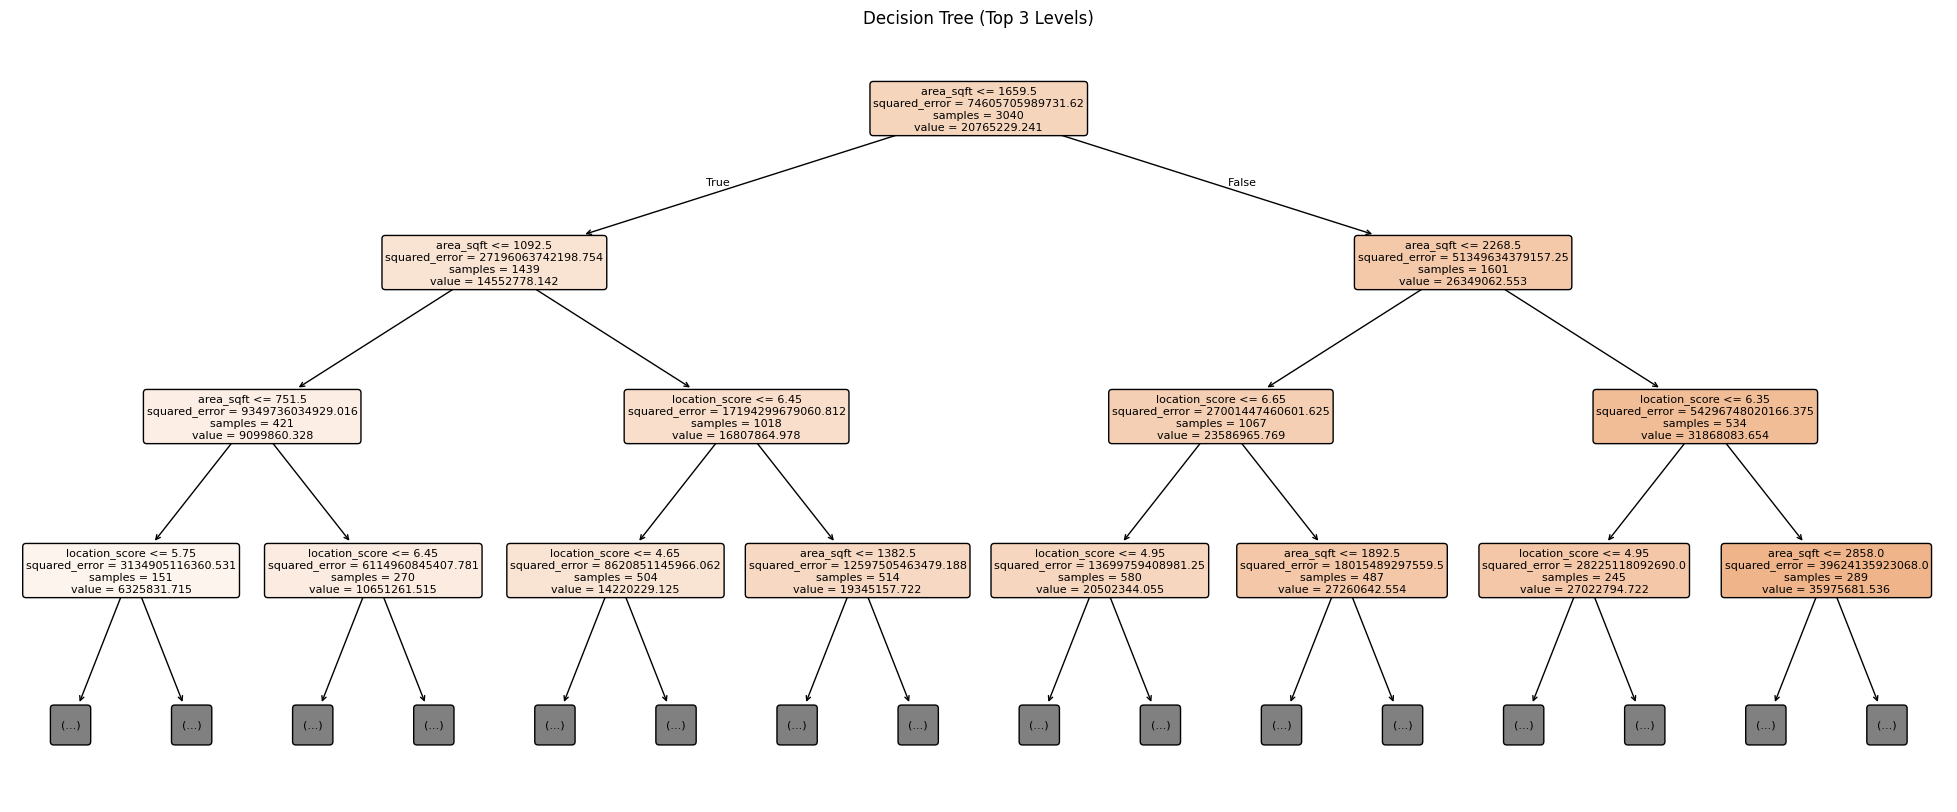

In [7]:
plt.figure(figsize=(25, 10))
plot_tree(model, max_depth=3, feature_names=FEATURES, filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree (Top 3 Levels)")
plt.show()

In [8]:
# check tree depth
print("Depth of Tree :", model.get_depth())

Depth of Tree : 22


In [9]:
# check total nodes
print("Number of Leaf Nodes :", model.get_n_leaves())

Number of Leaf Nodes : 3040


In [10]:
# total features used
print("Number of Features :", model.n_features_in_)

Number of Features : 9


In [11]:
# which column is important
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': model.feature_importances_
})

importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,area_sqft,0.741845
3,location_score,0.207898
4,property_age,0.015646
8,crime_rate_index,0.013694
5,distance_city_km,0.010320
1,bedrooms,0.003588
2,bathrooms,0.002933
7,near_metro,0.002746
6,near_school,0.001330


## Task 16 — Control Tree Complexity (Hyperparameters)

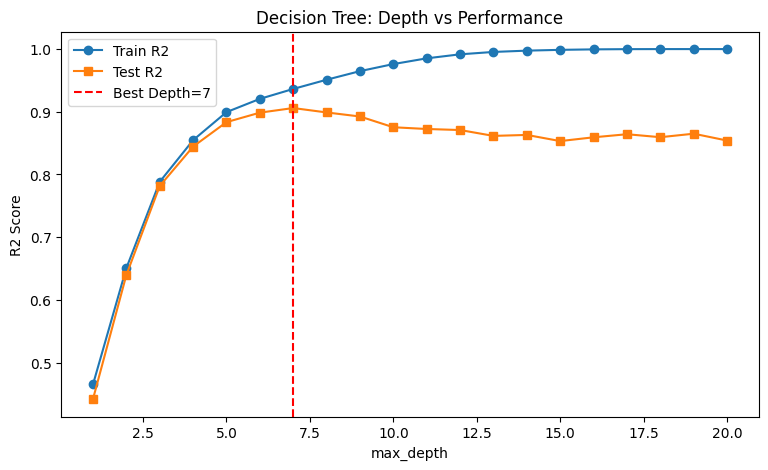

Best max_depth : 7


In [12]:
depths = range(1, 21)
train_r2 = []
test_r2  = []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_r2.append(m.score(X_train, y_train))
    test_r2.append(m.score(X_test, y_test))

best_depth = list(depths)[int(np.argmax(test_r2))]

plt.figure(figsize=(9, 5))
plt.plot(depths, train_r2, label='Train R2', marker='o')
plt.plot(depths, test_r2, label='Test R2', marker='s')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best Depth={best_depth}')
plt.xlabel('max_depth')
plt.ylabel('R2 Score')
plt.title('Decision Tree: Depth vs Performance')
plt.legend()
plt.show()

print("Best max_depth :", best_depth)

## Task 16 — Pre-Pruning

In [13]:
model2 = DecisionTreeRegressor(
    max_depth=best_depth,
    min_samples_split=12,
    min_samples_leaf=10,
    random_state=42
)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Training Score :", model2.score(X_train, y_train))
print("Testing Score  :", model2.score(X_test, y_test))

Training Score : 0.9318639341334576
Testing Score  : 0.9066493214425513


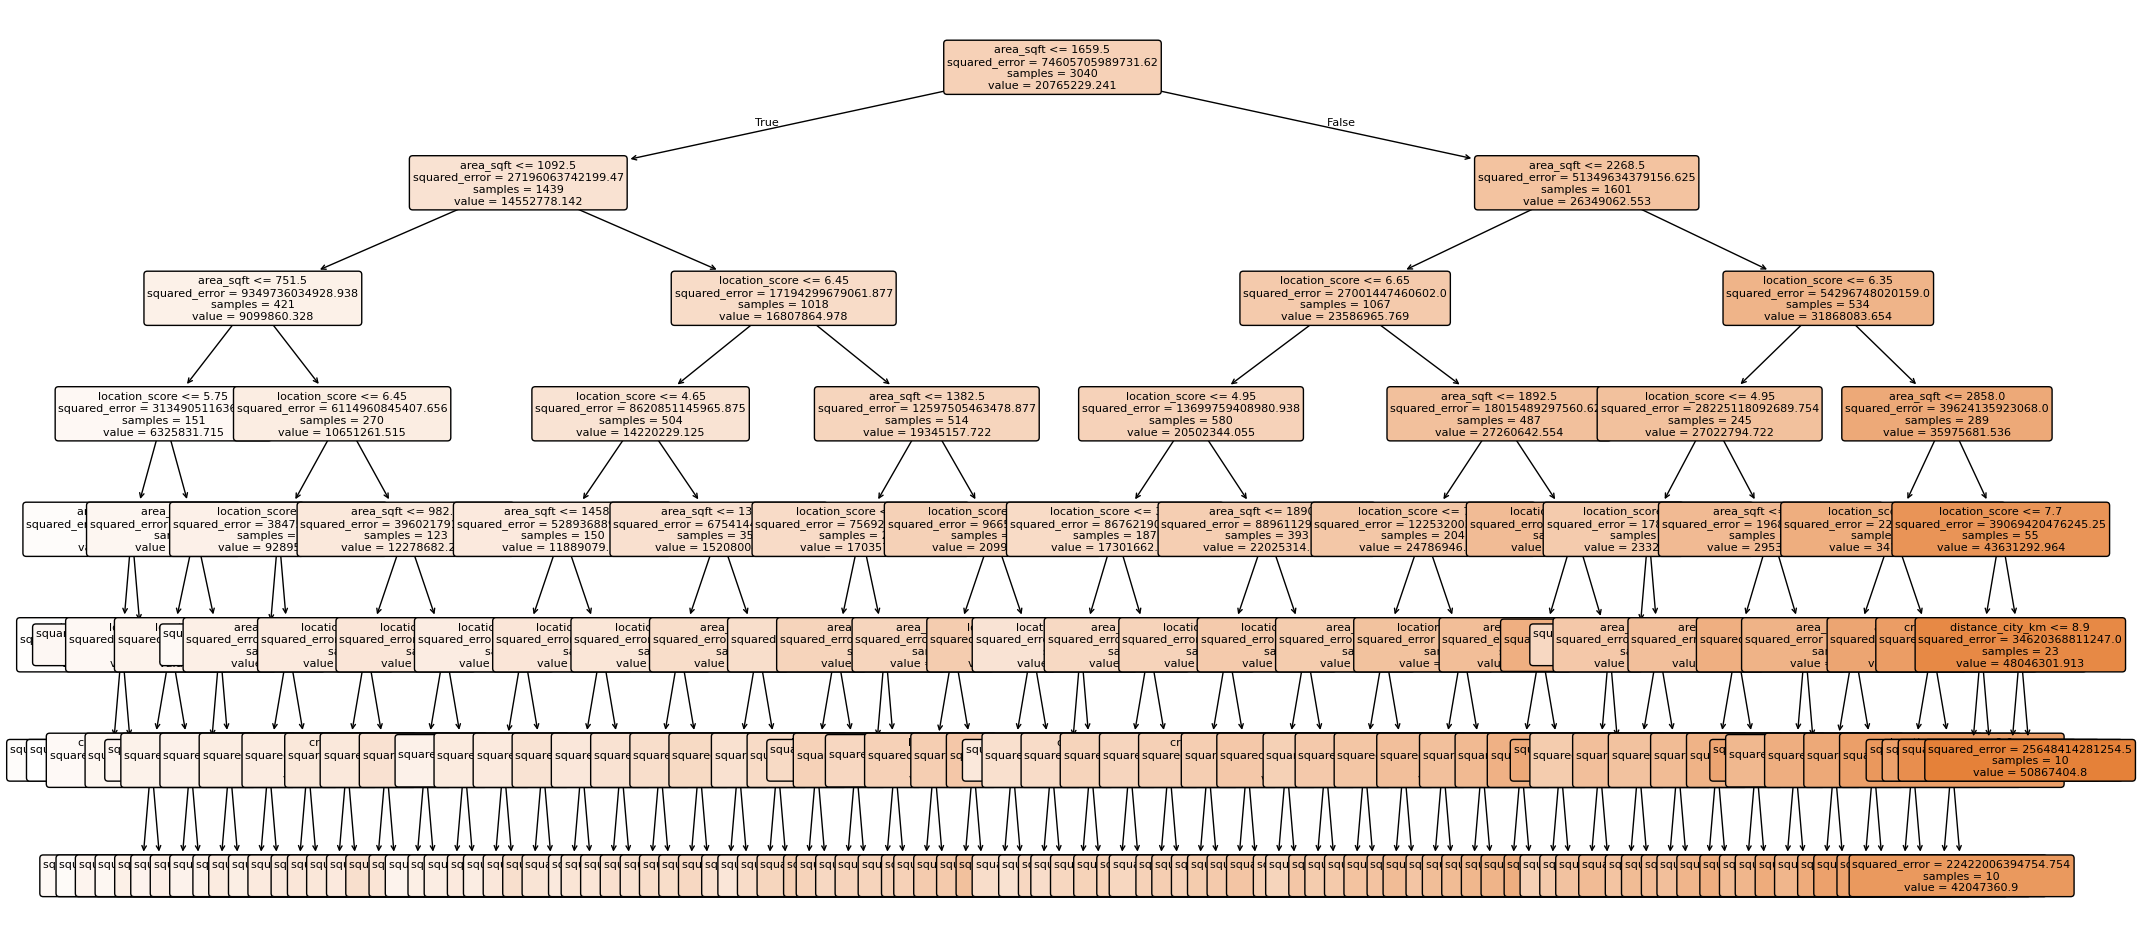

In [14]:
plt.figure(figsize=(25, 12))
plot_tree(
    model2,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

## Task 16 — Post-Pruning (Cost Complexity Pruning)

In [15]:
model_pruned = DecisionTreeRegressor(
    ccp_alpha=500000,
    random_state=42
)

model_pruned.fit(X_train, y_train)

y_pred_pruned = model_pruned.predict(X_test)

print("Old Model Train   :", model.score(X_train, y_train))
print("Old Model Test    :", model.score(X_test, y_test))
print("Pruned Model Train:", model_pruned.score(X_train, y_train))
print("Pruned Model Test :", model_pruned.score(X_test, y_test))

Old Model Train   : 1.0
Old Model Test    : 0.860354563895294
Pruned Model Train: 0.9999997127194509
Pruned Model Test : 0.8582140099323305


In [16]:
print("Old Tree Depth    :", model.get_depth())
print("Pruned Tree Depth :", model_pruned.get_depth())

print("Old Leaves    :", model.get_n_leaves())
print("Pruned Leaves :", model_pruned.get_n_leaves())

Old Tree Depth    : 22
Pruned Tree Depth : 22
Old Leaves    : 3040
Pruned Leaves : 2886


## Task 17 — Random Forest Regression

In [17]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [18]:
mae  = mean_absolute_error(y_test, y_pred_rf)
mse  = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_rf)

print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)
print("R2 Score :", r2)

MAE      : 1778261.3448157895
MSE      : 5842748489016.419
RMSE     : 2417177.7942502326
R2 Score : 0.9274509690787089


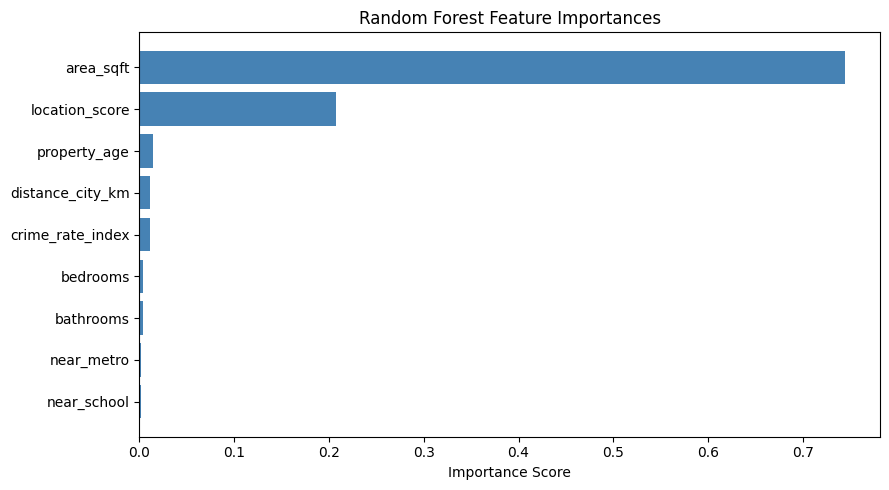

In [19]:
# Feature Importance
importance_rf = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf.feature_importances_
})

importance_rf = importance_rf.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(importance_rf['Feature'], importance_rf['Importance'], color='steelblue')
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Task 18 — Single Tree vs Ensemble

In [20]:
best_dt = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_dt.fit(X_train, y_train)

print(f"{'Model':<30} {'Train R2':>10} {'Test R2':>10} {'RMSE':>15}")
print("-" * 70)

for name, m, yp in [
    ('Decision Tree (default)', model, y_pred),
    (f'Decision Tree (depth={best_depth})', best_dt, best_dt.predict(X_test)),
    ('Random Forest (100 trees)', rf, y_pred_rf),
]:
    tr   = m.score(X_train, y_train)
    te   = m.score(X_test, y_test)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    print(f"{name:<30} {tr:>10.4f} {te:>10.4f} {rmse:>15,.0f}")

Model                            Train R2    Test R2            RMSE
----------------------------------------------------------------------
Decision Tree (default)            1.0000     0.8604       3,353,561
Decision Tree (depth=7)            0.9364     0.9059       2,752,289
Random Forest (100 trees)          0.9893     0.9275       2,417,178


## OOB Score — Random Forest

In [21]:
rf_oob = RandomForestRegressor(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

rf_oob.fit(X_train, y_train)

print("OOB Score :", rf_oob.oob_score_)

OOB Score : 0.921664347139248
